## Problem 2

#### 1. Plot the spectrum 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 6000

rng = np.random.default_rng(42)

matrix = np.zeros((N, N))

#generate symmetric matrix
for i in range(N):
    for j in range(N):
        if i <= j:
            matrix[i, j] = rng.normal(0, 1)

for i in range(N):
    for j in range(N):
        if i > j:
            matrix[i, j] = matrix[j, i]

eigvals = np.linalg.eigvals(matrix)


#### Wigner semi-circle

Wigner semicircle distribution has one parameter - radius of the circle $R$. The variance of this distribution is $\frac{R^2}{4}$, so we can estimate $R$

In [2]:
def std(x: np.ndarray) -> float:
    return np.sqrt(np.sum((x - x.mean())**2) / (len(x) - 1))

R = 2 * std(eigvals)

print(R)

154.8985038611998


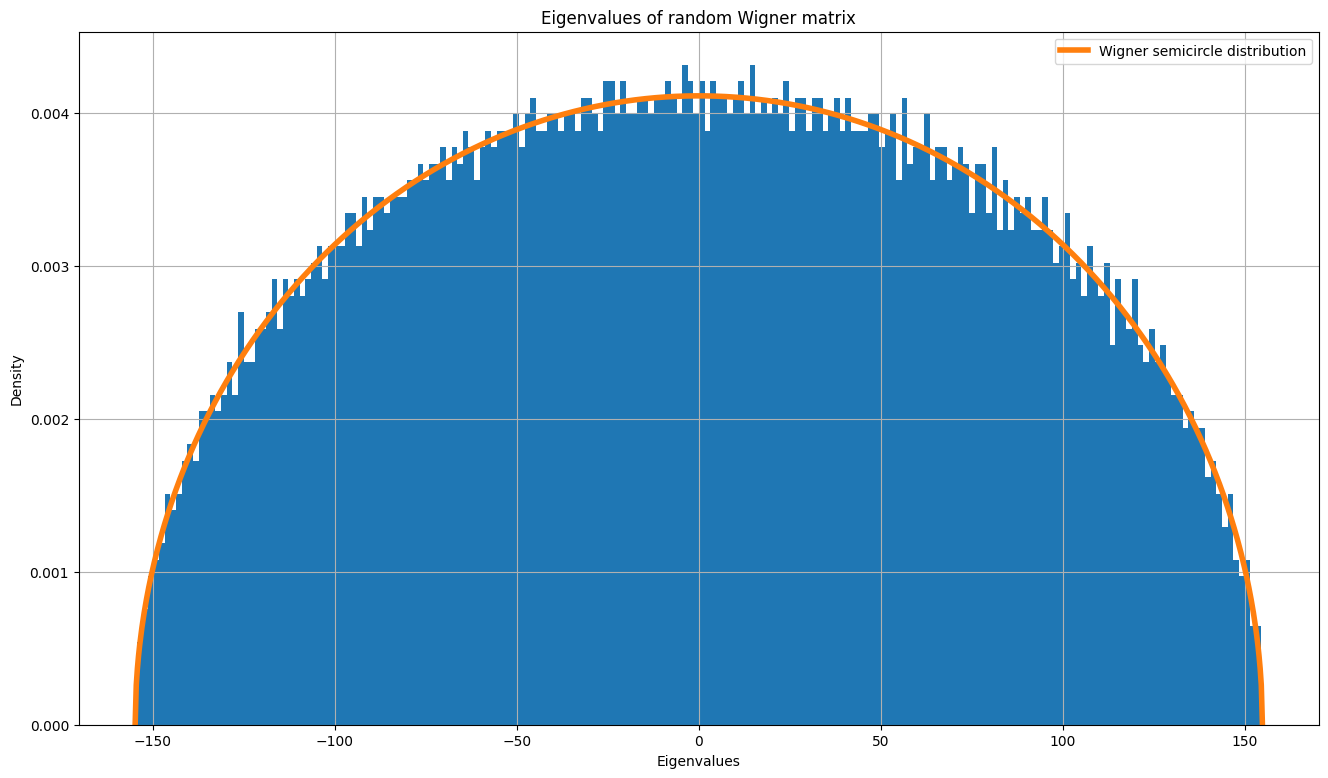

In [3]:
x = np.linspace(-R, R, 1000)
y = 2 * np.sqrt(R**2 - x**2) / np.pi / R**2
plt.figure(figsize=(16, 9))
plt.hist(eigvals, bins=200, density=True)
plt.plot(x, y, label='Wigner semicircle distribution', linewidth=4)
plt.xlabel('Eigenvalues')
plt.ylabel('Density')
plt.title('Eigenvalues of random Wigner matrix')
plt.grid(True)
plt.legend()
plt.show()

#### Wigner’s surmise

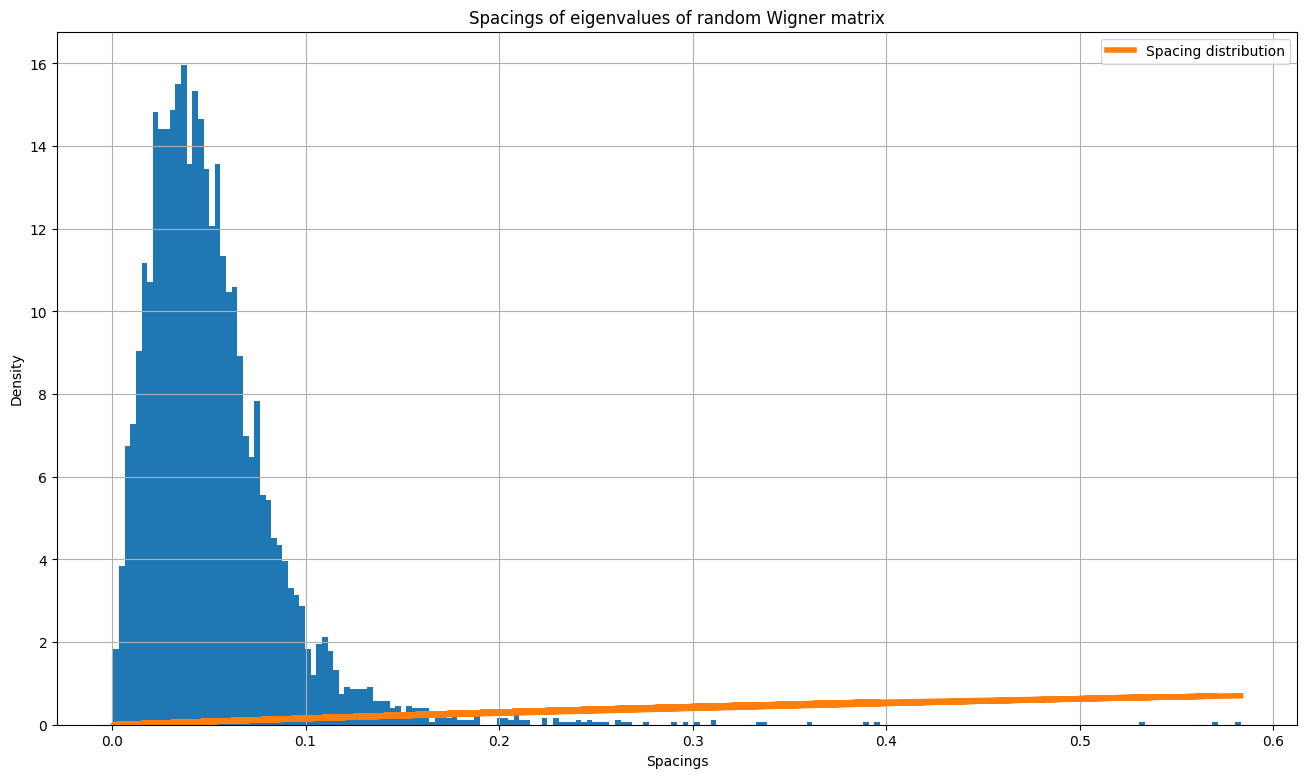

In [4]:
spacings = np.diff(np.sort(eigvals))

y = np.pi * spacings * np.exp( - np.pi * spacings**2 / 4) / 2

plt.figure(figsize=(16, 9))
plt.hist(spacings, bins=200, density=True)
plt.plot(spacings, y, label='Spacing distribution', linewidth=4)
plt.xlabel('Spacings')
plt.ylabel('Density')
plt.title('Spacings of eigenvalues of random Wigner matrix')
plt.grid(True)
plt.legend()
plt.show()


As we can see, the density does not fit the distribution. Lets find the precise form of distribution.

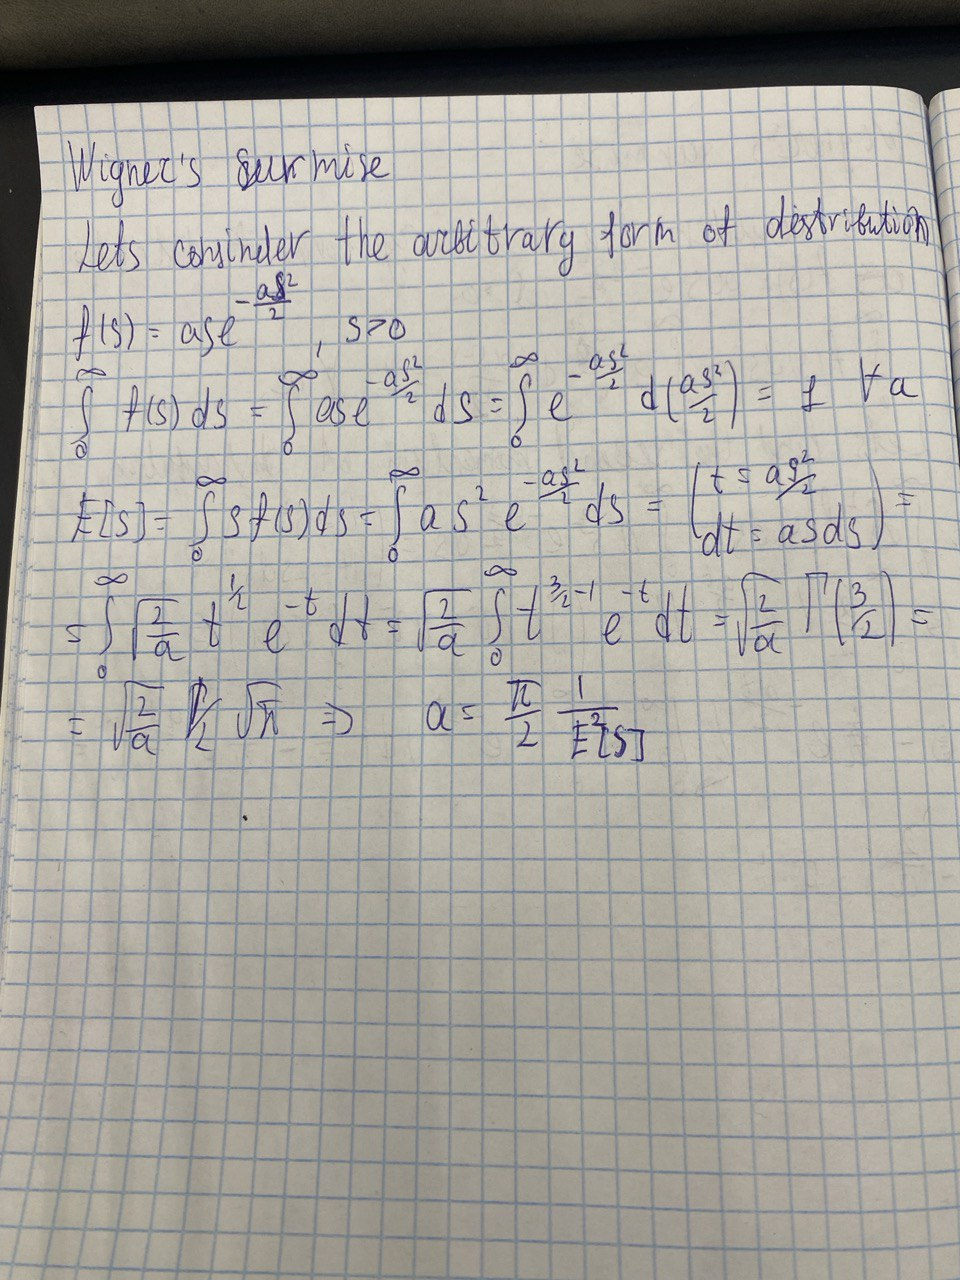

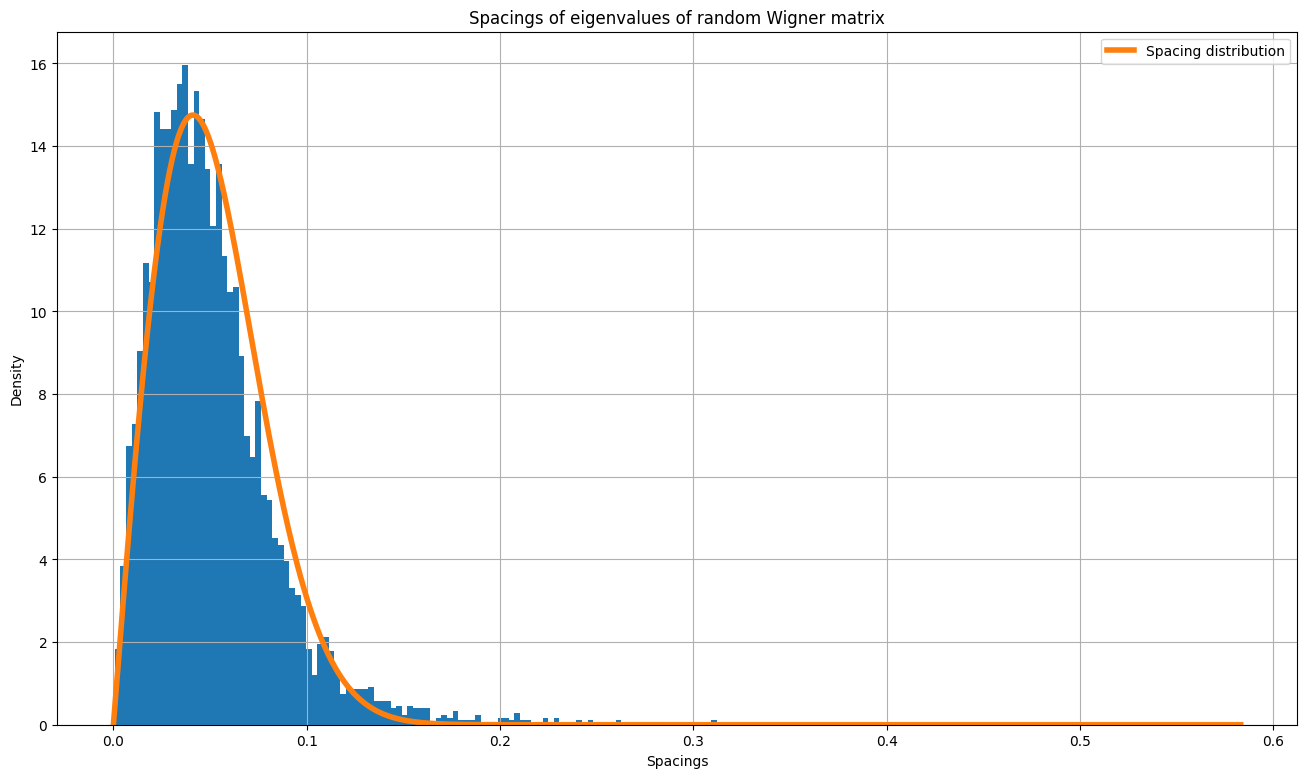

In [5]:
a_param = np.pi / 2 / spacings.mean()**2

x = np.linspace(0, spacings.max(), 1000)
y = a_param * x * np.exp( - a_param * x**2 / 2)

plt.figure(figsize=(16, 9))
plt.hist(spacings, bins=200, density=True)
plt.plot(x, y, label='Spacing distribution', linewidth=4)
plt.xlabel('Spacings')
plt.ylabel('Density')
plt.title('Spacings of eigenvalues of random Wigner matrix')
plt.grid(True)
plt.legend()
plt.show()

#### Tracy-Widom

In [6]:
from tqdm import tqdm
max_eigvals = np.zeros(1000)

N = 1000

for k in tqdm(range(1000)):
    matrix_k = np.zeros((N, N))

    #generate symmetric matrix
    for i in range(N):
        for j in range(N):
            if i <= j:
                matrix_k[i, j] = rng.normal(0, 1)

    for i in range(N):
        for j in range(N):
            if i > j:
                matrix_k[i, j] = matrix_k[j, i]

    max_eigvals[k] = np.linalg.eigvals(matrix_k).max()


100%|██████████| 1000/1000 [15:09<00:00,  1.10it/s]


Text(0.5, 1.0, 'Max eigenvalue of random matrix')

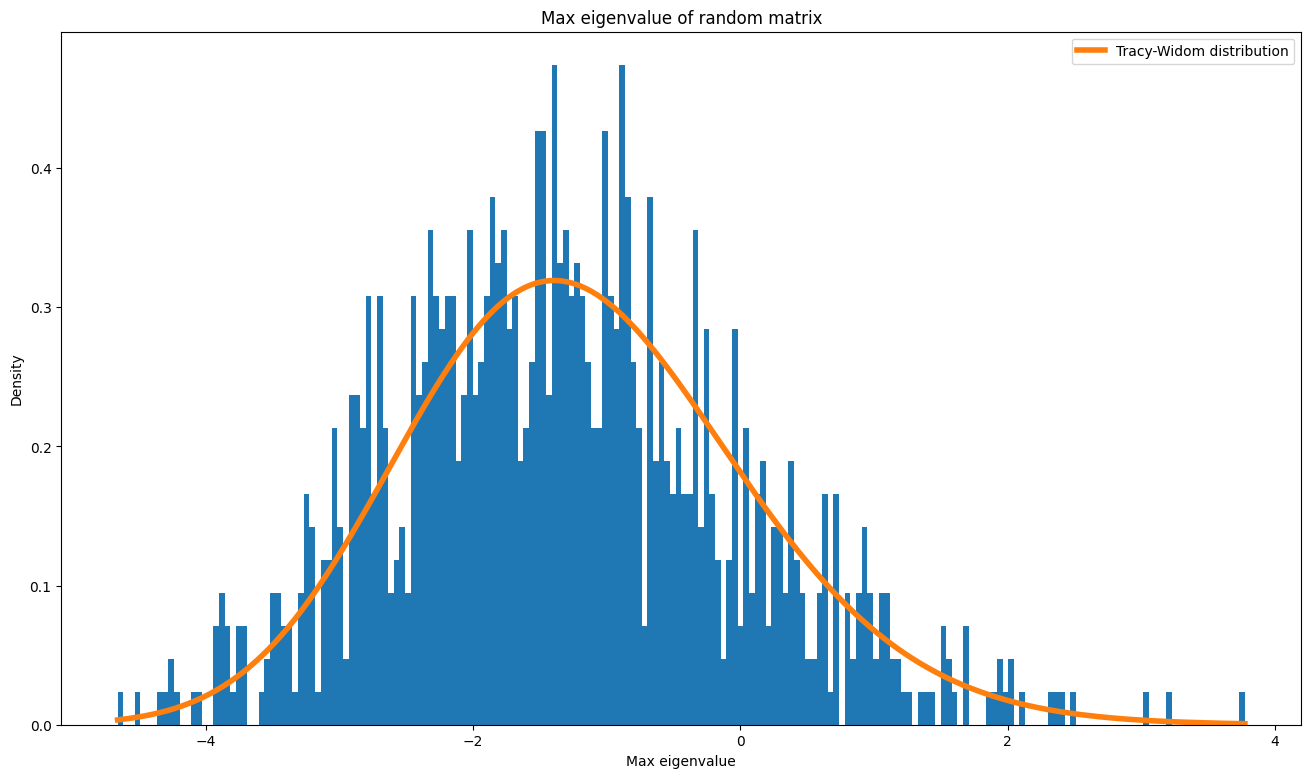

In [23]:
from skrmt.ensemble.spectral_law import TracyWidomDistribution

normalized_max_eigvals = N**(2/3) * (max_eigvals / np.sqrt(N) - 2.0)

x = np.linspace(normalized_max_eigvals.min(), normalized_max_eigvals.max(), 1000)
twd = TracyWidomDistribution(beta=1)
y_pdf = twd.pdf(x)

plt.figure(figsize=(16, 9))
plt.hist(normalized_max_eigvals, bins=200, density=True)
plt.plot(x, y_pdf, label='Tracy-Widom distribution', linewidth=4)
plt.xlabel('Max eigenvalue')
plt.ylabel('Density')
plt.legend()
plt.title('Max eigenvalue of random matrix')

## Problem 3

#### Write a function that produces a sum $Z = X_1 + ... + X_N$

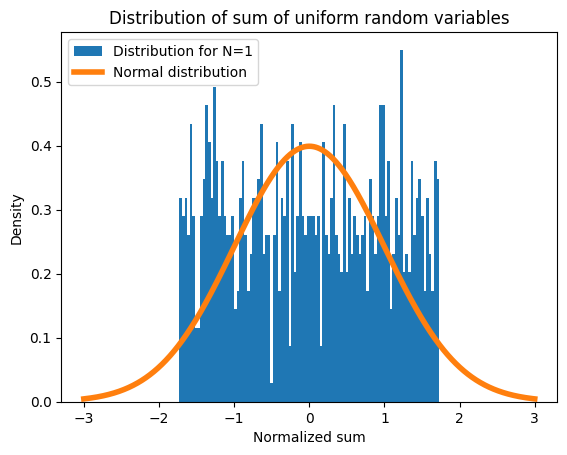

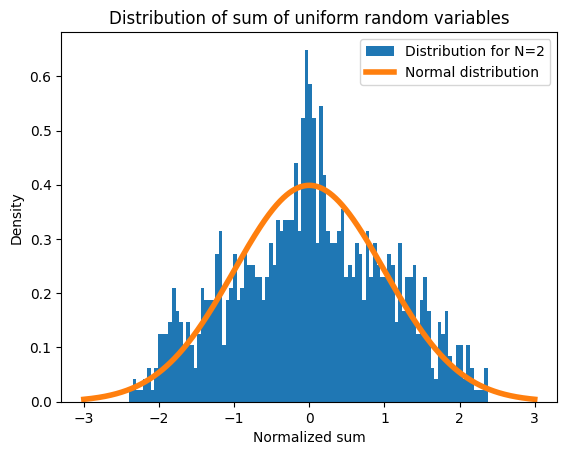

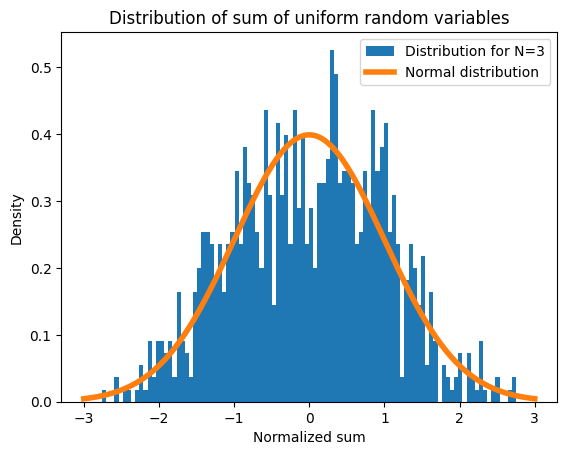

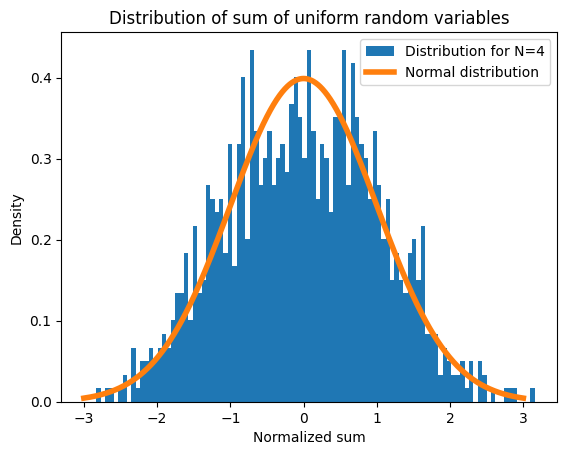

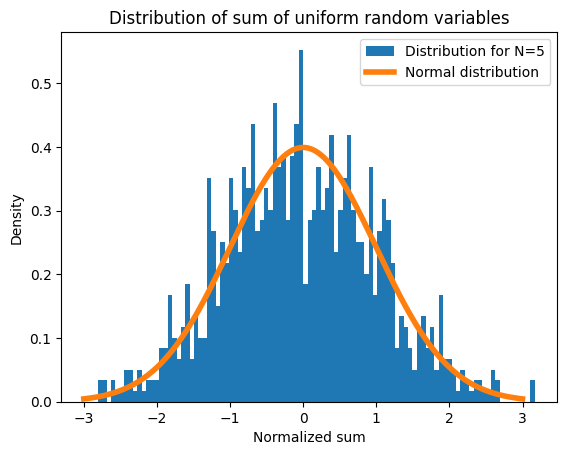

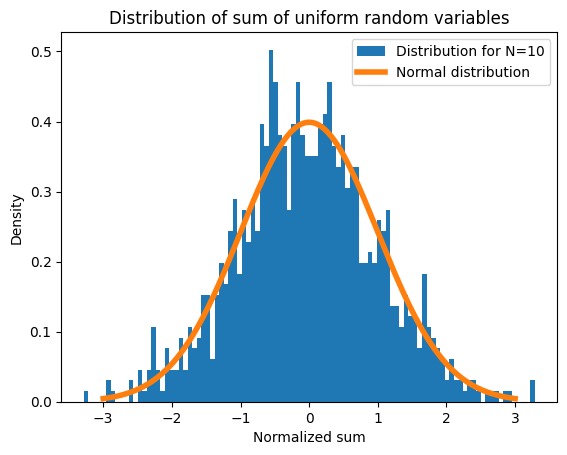

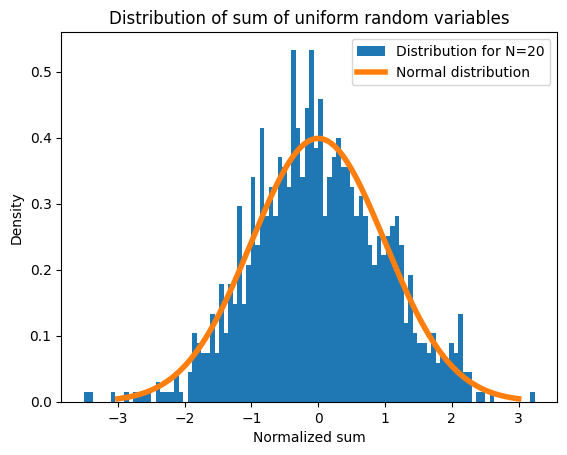

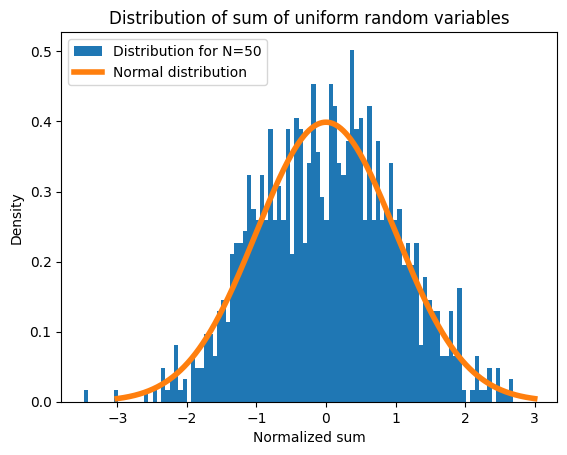

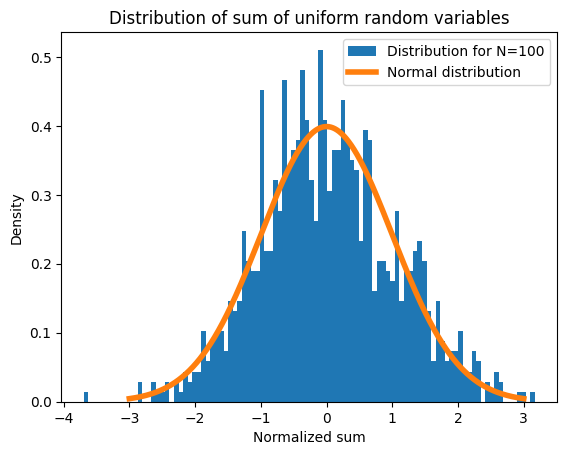

In [4]:
import numpy as np
import matplotlib.pyplot as plt

class RandomGenerator():
    """Generate sum of uniform random variables"""
    def __init__(self, N, seed=42):
        self.N = N
        self.rng = np.random.default_rng(seed)

    def generate(self, n_samples = 1):

        return np.sum(self.rng.uniform(0, 1, (n_samples, self.N)), axis=1)

    def generate_normalized(self, n_samples = 1):
        samples = self.generate(n_samples)
        return (samples - 0.5 * self.N) / np.sqrt(self.N / 12)

x = np.linspace(-3, 3, 1000)
normal_pdf = np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)

for N in [1, 2, 3, 4, 5, 10, 20, 50, 100]:
    rgn = RandomGenerator(N)
    samples = rgn.generate_normalized(1000)

    plt.hist(samples, bins=100, density=True, label=f'Distribution for N={N}')
    plt.plot(x, normal_pdf, label='Normal distribution', linewidth=4)
    plt.xlabel('Normalized sum')
    plt.ylabel('Density')
    plt.legend()
    plt.title('Distribution of sum of uniform random variables')
    plt.show()

